[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/streaming-interruption.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239464-lesson-1-streaming)

# Streaming

## 回顧

在 module 2 中，我們介紹了幾種自訂 graph state 與 memory 的方式。
 
我們一路打造出一個具備外部 memory 的 Chatbot，可以維持長時間的對話。

## 目標

本 module 將深入 `human-in-the-loop`，它建立在 memory 之上，讓使用者能以各種方式直接與 graph 互動。

為了替 `human-in-the-loop` 鋪好基礎，我們會先深入 streaming，它提供了多種方式來視覺化 graph 在執行過程中的輸出（例如 node state 或 chat model tokens）。

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk

## Streaming

LangGraph 在設計上就[原生支援 streaming](https://docs.langchain.com/oss/python/langgraph/streaming)。

讓我們先把 Module 2 的 Chatbot 設定好，並展示在執行過程中從 graph 串流輸出的各種方式。

In [15]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

請注意，我們在 `call_model` 中使用 `RunnableConfig` 來啟用逐 token 的 streaming。這[只有在 python < 3.11 時才需要](https://langchain-ai.github.io/langgraph/how-tos/streaming-tokens/)。我們在這裡加上它，以防你是在 CoLab 上執行這個 notebook，因為 CoLab 會用 python 3.x。

graph LR
    A["graph.invoke/stream(config)"] --> B["call_model(state, config)"]
    B --> C["model.invoke(messages, config)"]
    C --> D["callbacks 觸發 token streaming"]


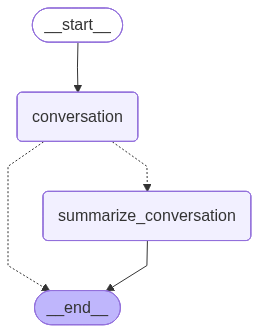

In [ ]:
from IPython.display import Image, display
from typing import Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig


from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# 這個 model 沒有 bind_tools，本 notebook 前半段就是一個純聊天 + 自動摘要的 chatbot。
model = ChatOpenAI(model="gpt-4o", temperature=0) 

# 繼承 MessagesState，而不是自己從零寫一個 TypedDict。
# MessagesState 已經內建一個 messages 欄位，而且掛好了 add_messages reducer
# （新 message 會「追加」而不是「覆蓋」）。繼承它 = 白拿這個 reducer，
# 只要補自己多出來的欄位就好。這裡多的是 summary：舊對話濃縮後的一段文字。
class State(MessagesState):
    summary: str

# ⚠️ 全 notebook 最隱晦的一行，卻是後面 token streaming 的總開關。
#
# 這個 node 為什麼要多收一個 config、又原封不動塞給 model.invoke？
# config 裡藏著 LangGraph 的 callback handlers。LLM 每吐一個 token 就往 callback
# 回報一次，LangGraph 靠 config 這條線才知道「這個 token 是 conversation node 吐的」。
# config 沒往下傳 = 線斷了 = 後面 astream_events 抓不到這個 node 的 token。
#
# Python 3.11+ 有 contextvars 會自動幫你傳，不寫也會動；3.11 以下沒有這個機制，
# 一定要手動傳。教材這樣寫是為了讓 Colab（python < 3.11）也跑得起來。
#
# ⚠️ 踩雷：線斷了不會報錯。graph 照跑、回答照出，只是後面過濾 token 那幾格
#    會安靜地印不出任何東西，因為 event['metadata'] 裡根本不會有 langgraph_node。
def call_model(state: State, config: RunnableConfig):

    # 取得 summary（如果存在的話）
    summary = state.get("summary", "")

    # 如果有 summary，就把它加進去
    if summary:

        # 把 summary 加進 system message
        system_message = f"Summary of conversation earlier: {summary}"

        # 把 summary 接在較新的 messages 前面
        messages = [SystemMessage(content=system_message)] + state["messages"]

    else:
        messages = state["messages"]

    response = model.invoke(messages, config)
    # node 回傳的是「要對 state 做什麼」的意向單，不是新的 state 本體。
    # add_messages reducer 收到這則 AIMessage 會追加到 messages 後面，
    # 而不是把整份 list 換掉。這個心智模型是下面 RemoveMessage 的前提。
    return {"messages": response}

def summarize_conversation(state: State):

    # 首先，取得任何已存在的 summary
    summary = state.get("summary", "")

    # 建立我們的 summarization prompt
    if summary:

        # 已經存在一份 summary
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )

    else:
        summary_message = "Create a summary of the conversation above:"

    # 把 prompt 加進我們的對話歷史
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    # 注意這裡沒傳 config（上面的 call_model 有傳）。教材本身的不一致：
    # 在 python 3.11+ 靠 contextvars 自動補上所以沒差，3.11 以下這個 node 的 token
    # 就串不出來。要嚴謹的話這裡也該寫成 model.invoke(messages, config)。
    response = model.invoke(messages)

    # ⚠️ 反直覺到像筆誤：刪掉 message 的方法，是「新增一則 RemoveMessage」。
    #
    # 為什麼不能直接 state["messages"].pop()？因為 state 的更新一律要經過 reducer。
    # node 只能回傳「更新意向」交給 reducer 去執行，自己動手改 list 是改到副本，
    # reducer 沒收到指令，存進 checkpoint 的還是舊的。
    # add_messages reducer 的規則是：看到 RemoveMessage，就把 id 對得上的那則刪掉。
    # 所以 RemoveMessage 不是一則訊息，是一張「請刪掉 id=xxx 那則」的指令單。
    #
    # [:-2] = 只留最後 2 則（剛才那輪的一問一答），前面全刪，
    # 因為它們的內容已經被壓進 summary 了, 以達到節省記憶體的目的。
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# 判斷要結束對話，還是要對對話做 summarize
def should_continue(state: State)-> Literal ["summarize_conversation",END]:

    """回傳下一個要執行的 node。"""

    messages = state["messages"]

    # 如果 messages 超過六則，就對對話做 summarize
    if len(messages) > 6:
        return "summarize_conversation"

    # 否則就直接結束
    return END

# 定義一個新的 graph
workflow = StateGraph(State)
# ⚠️ 兩種 add_node 寫法，node 名字的來源不一樣：
#   add_node("conversation", call_model) → 名字是你指定的 "conversation"
#   add_node(summarize_conversation)     → 沒給名字，LangGraph 拿函式名當 node 名
# 這個名字不是裝飾用的：後面 stream_mode="updates" 印出來的外層 key、
# 以及過濾 token 用的 event['metadata']['langgraph_node']，用的都是它。
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# 把進入點（entrypoint）設為 conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
# checkpointer = 每跑完一個 node 就把 state 存一次檔。
# 沒有它，下面每個 thread_id 都是空的，多輪對話與 summary 都累積不起來。
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### Streaming full state

接下來，我們來談談[串流 graph state](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes) 的幾種方式。

`.stream` 與 `.astream` 分別是串流回傳結果的同步與非同步方法。
 
針對 graph state，LangGraph 支援幾種[不同的 streaming 模式](https://docs.langchain.com/oss/python/langgraph/streaming#stream-graph-state)。
 
* `values`：每次呼叫 node 之後，串流 graph 的完整 state。
* `updates`：每次呼叫 node 之後，串流 graph state 的更新部分。

![values_vs_updates.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbaf892d24625a201744e5_streaming1.png)

我們先來看 `stream_mode="updates"`。

因為我們用 `updates` 串流，所以每個 graph node 跑完之後，只會看到 state 的更新部分。

每個 `chunk` 都是一個 dict，key 是 `node_name`，value 則是更新後的 state。

In [5]:
# thread_id = 這次對話的「存檔名稱」。跑完的每個 state 都掛在它底下串成時間線。
# 下面幾格會一直換 thread_id（"2"、"3"…），等於每次都開一個新存檔重聊，
# 才不會被前一輪的 messages 干擾示範。
config = {"configurable": {"thread_id": "1"}}

# ⚠️ 上面的段落標題叫「Streaming full state」，但這格示範的其實是 updates（差異）。
#    full state 要看再下面 stream_mode="values" 那格。教材的標題會帶偏，先講清楚。
#
# stream_mode="updates" → 每個 node 跑完，只吐「這個 node 改了什麼」。
# 印出來長這樣：{'conversation': {'messages': AIMessage(...)}}
#                ^^^^^^^^^^^^^^ 外面先包一層 node 名字，再進去才是那個 node 的回傳值。
# 對照組（values）→ 吐當下的完整 state：{'messages': [...全部...]}，沒有 node 名字這層。
# 這個「多一層 / 少一層」的不對稱是本章第一個必卡點，在這裡先看清楚。
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='Hello Lance! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_94cd41efba', 'id': 'chatcmpl-E2EvuTsnB1KxaIM8qCqYWl8MoFUim', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6ac5-a781-7932-8968-e3109420e1d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


{'conversation': {'messages': AIMessage(content='Hello Lance! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_94cd41efba', 'id': 'chatcmpl-E2EvuTsnB1KxaIM8qCqYWl8MoFUim', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6ac5-a781-7932-8968-e3109420e1d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}

現在我們改成只印出 state 的更新部分。

In [6]:
# 這格沿用上一格的 config（thread_id 還是 "1"），所以是「接著上面那輪繼續聊」，
# 不是重跑。state 裡此刻已經有前一輪的一問一答了。
#
# chunk['conversation']["messages"] 為什麼要剝兩層？
#   'conversation' → updates 模式在外面包的 node 名字（就是 add_node 時取的那個）
#   "messages"     → call_model 回傳的那個 dict 裡的 key
# 對照下面 values 那格直接寫 event['messages']，少剝一層。差別只來自 stream_mode。
#
# ⚠️ 踩雷：這行把 'conversation' 寫死了。哪天對話長到觸發 summarize_conversation，
#    那個 node 吐回來的是 {'summarize_conversation': {...}}，這行就 KeyError。
#    當示範夠用，別直接抄進正式程式碼。
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Hi Lance! How's it going? What can I do for you today?


現在我們來看 `stream_mode="values"`。

這是 `conversation` node 被呼叫之後，graph 的 `full state`。

In [7]:
# 換 thread_id="2" = 開新存檔，前面那輪完全不存在，
# 這樣才看得出 values 每一步吐的「完整 state」是怎麼長出來的。
config = {"configurable": {"thread_id": "2"}}

# stream_mode="values" → 每一步吐「當下的完整 state」，不是差異。
# 所以這裡直接 event['messages'] 就拿得到，不用像 updates 那樣先剝掉 node 名字。
#
# 看 output：會印兩輪。第一輪只有 Human（graph 剛把 input 寫進 state），
# 第二輪 Human + AI（conversation node 跑完了）。同一則 Human 被重印，
# 正是因為 values 每次都把全部給你，不是只給新增的那則。
input_message = HumanMessage(content="hi! I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello Lance! How can I assist you today?
---------------------------------------------------------------------------


### Streaming tokens

我們經常想串流的不只是 graph state。

尤其是在呼叫 chat model 時，很常見的需求是隨著 token 產生而即時串流它們。

我們可以[用 `.astream_events` 方法](https://docs.langchain.com/oss/python/langchain/models#advanced-streaming-topics:streaming-events)來做到這件事，它會在 node 內部發生事件時，把這些 events 串流回來！

每個 event 都是一個 dict，包含幾個 key：
 
* `event`：這是被發出的 event 類型。
* `name`：這是 event 的名稱。
* `data`：這是與該 event 相關的資料。
* `metadata`：包含 `langgraph_node`，也就是發出該 event 的 node。

我們來看看。

In [8]:
# .stream() vs .astream_events()：解析度差一個數量級的兩台攝影機。
#   .stream()         → node 層級的進度：「conversation 跑完了，結果是這個」
#   .astream_events() → 細到 node 內部發生的每一件事，包含 LLM 每吐一個 token
# 要做打字機效果，只有後者辦得到。
#
# version="v2" 不是隨手寫的版本號，是 event schema 的版本。v1 / v2 的欄位結構不同，
# 抄網路上的程式碼發現 key 對不上，通常就是版本不一樣。
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
# 這格會噴出一大坨東西，而且是刻意的：先讓你看見事件流裡混著多少雜訊
# （on_chain_start、on_chat_model_start… 什麼都有），
# 下一格才知道為什麼非過濾不可。
#
# 每個 event 認這三個欄位就夠：
#   event['event']    → 事件類型，on_chat_model_stream 就是「LLM 正在吐 token」
#   event['metadata'] → 上下文，langgraph_node 藏在這（就是 call_model 傳 config 換來的）
#   event['name']     → 誰發的，例如 ChatOpenAI
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. N

重點在於：你 graph 內 chat models 產生的 token，其類型是 `on_chat_model_stream`。

我們可以用 `event['metadata']['langgraph_node']` 來選擇要從哪個 node 串流。

並且可以用 `event['data']` 取得每個 event 的實際資料，在這個情況下就是一個 `AIMessageChunk`。

In [9]:
# ⚠️ 踩雷：這個字串必須和 add_node 取的 node 名字一模一樣。
#    打錯不會報錯，只會一個 token 都印不出來。
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # 兩個條件缺一不可，各擋掉一種雜訊：
    #   on_chat_model_stream → 從上一格那一大坨事件裡，只留「LLM 正在吐 token」這種
    #   langgraph_node       → 只留「是 conversation 這個 node 吐的」
    #
    # 為什麼還要篩 node？因為這張 graph 裡 conversation 和 summarize_conversation
    # 兩個 node 都會呼叫 LLM。不篩的話，摘要用的 token 會跟回答用的 token 混在一起噴出來，
    # 使用者的聊天視窗就會莫名其妙冒出一段摘要。
    #
    # 而 metadata 裡之所以有 langgraph_node 可以篩，正是 call_model 把 config
    # 往下傳的回報。那裡沒傳，這個條件就永遠篩不到東西。
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        # data 是個 dict，token 包在 data["chunk"] 裡（下一格會拆出來用）
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019f6ad3-86ee-77a0-a148-84ce36808137', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='The', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019f6ad3-86ee-77a0-a148-84ce36808137', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' San', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019f6ad3-86ee-77a0-a148-84ce36808137', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' Francisco', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019f6ad3-86ee-77a0-a148-84ce36808137', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' ', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id=

如同上面所見，只要用 `chunk` 這個 key 就能取得 `AIMessageChunk`。

In [10]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # 從特定的 node 取得 chat model tokens
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        # chunk 是 AIMessageChunk：一整則 AIMessage 的一小片，通常一兩個字，
        # .content 才是文字本身。把這些 chunk 依序接起來就是完整回答。
        #
        # end="|" 純粹是教學用的：把 token 邊界畫出來，讓你肉眼看見
        # 「模型不是一次吐一句，是一小塊一小塊吐」。正式做打字機效果時用 end="" 即可。
        print(data["chunk"].content, end="|")

|The| San| Francisco| |49|ers| are| a| professional| American| football| team| based| in| the| San| Francisco| Bay| Area|.| They| compete| in| the| National| Football| League| (|NFL|)| as| a| member| of| the| league|'s| National| Football| Conference| (|N|FC|)| West| division|.| The| team| was| founded| in| |194|6| as| a| charter| member| of| the| All|-Amer|ica| Football| Conference| (|AA|FC|)| and| joined| the| NFL| in| |194|9| when| the| leagues| merged|.

|###| Key| Points|:

|-| **|St|adium|**|:| The| |49|ers| play| their| home| games| at| Levi|'s| Stadium| in| Santa| Clara|,| California|,| which| they| moved| to| in| |201|4|.| Before| that|,| they| played| at| Cand|lestick| Park| in| San| Francisco|.

|-| **|Team| Colors|**|:| The| team's| colors| are| red|,| gold|,| and| white|.

|-| **|Masc|ot|**|:| The| team's| mascot| is| S|ourd|ough| Sam|.

|-| **|Champ|ionship|s|**|:| The| |49|ers| have| won| five| Super| Bowl| championships| (|Super| Bowl| XVI|,| XIX|,| XX|III|,| XX|IV|,| a

### Streaming with LangGraph API

**⚠️ 注意**

自從拍攝這些影片以來，我們已更新了 Studio，現在它可以在本機執行並透過你的瀏覽器存取。這是執行 Studio 的建議方式，取代影片中所示的 Desktop App。它現在改名為 _LangSmith Studio_，而非 _LangGraph Studio_。詳細的設定說明可在課程開頭的「Getting Setup」指南中找到。你可以在[這裡](https://docs.langchain.com/langsmith/studio)找到 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的具體細節。  
若要啟動本機開發伺服器，請在終端機中切換到本 module 的 `/studio` 目錄，並執行以下指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器，並前往上面顯示的 **Studio UI** 網址。

LangGraph API [支援編輯 graph state](https://docs.langchain.com/langsmith/add-human-in-the-loop)。

In [11]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

Server 現在在背景跑（log 在 scratchpad 的 langgraph-dev.log）。之後自己要開的話：

cd docs/langchain-academy/langgraph/langgraph-important-module/module-3/studio
langgraph dev --no-browser

In [13]:
# 分水嶺：從這格開始，graph 不在 notebook 裡了。
# 前面是 graph.stream() 直接在這個 process 內跑；
# 這裡改成用 SDK client 透過 HTTP 打一台 langgraph dev server。
# 對照的價值在於：同一套 streaming 概念，跨程序之後長什麼樣、哪裡會變。
from langgraph_sdk import get_client

# 本機開發伺服器的 URL（langgraph dev 預設就開在 2024 port）
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# ⚠️ 前提揭露（教材完全沒講，學員必卡）：這台 server 上跑的 graph 是 studio/agent.py，
#    一個綁了 add / multiply / divide 三個 tool 的 agent，
#    不是這個 notebook 上半部那個 summarize chatbot。
#    所以下面才會突然改問「Multiply 2 and 3」——不是換題目，是換了一整張 graph。
#    下面 assistant_id="agent" 的 "agent" 這個名字，來自 studio/langgraph.json 的 graphs 設定。
assistants = await client.assistants.search()

我們來像之前一樣[串流 `values`](https://docs.langchain.com/oss/python/langgraph/streaming#stream-graph-state)。

In [14]:
# 本機版是自己隨手編一個 thread_id="1"；這裡改由 server 建立 thread 並把 id 發還給你。
# 概念一樣是「存檔」，只是存在 server 上而不是這個 process 的記憶體裡。
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")
# 同樣是 stream_mode="values"，但吐回來的東西換了包裝：
#   本機 graph.stream() → 直接給你 dict，寫 event['messages']
#   SDK client.runs.stream() → 給你 StreamPart 物件，要用 .event（類型）和 .data（內容）取
# 更關鍵的是：.data 裡的 messages 是走過 HTTP / JSON 的純 dict，不是 AIMessage 物件，
# 沒有 .content 也沒有 .pretty_print()。這就是下一格非得 convert_to_messages 的原因。
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '019f6ad9-e397-7f10-8a65-a71867a2137d', 'attempt': 1}, id=None)
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '593a0c88-e9bc-4a62-bee9-1c4f1a75a15d'}]}, id=None)
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '593a0c88-e9bc-4a62-bee9-1c4f1a75a15d'}, {'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549'

串流回來的物件包含：

* `event`：類型
* `data`：State

In [13]:
# convert_to_messages = 把過完 HTTP 變成純 dict 的 messages 組回 Message 物件，
# 這樣才有 .pretty_print()、.content 可以用。本機版不需要這步，因為物件從沒離開過 process。
from langchain_core.messages import convert_to_messages
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")
async for event in client.runs.stream(thread["thread_id"], assistant_id="agent", input={"messages": [input_message]}, stream_mode="values"):
    # ⚠️ 為什麼要 .get(..., None) 而不是 event.data['messages']？
    #    因為第一個吐回來的 event 是 metadata，它的 data 裡根本沒有 messages key，
    #    直接用中括號取會 KeyError。
    messages = event.data.get('messages',None)
    if messages:
        print(convert_to_messages(messages)[-1])
    print('='*25)

content='Multiply 2 and 3' additional_kwargs={} response_metadata={} id='c3ec872a-99a1-4eec-bcb6-a04973f48ac5'
content='' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 134, 'output_tokens': 17, 'total_tokens': 151, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f64f290af2', 'id': 'chatcmpl-CSqw6HYoyCI7z2AuKAAfSTQGbvzla', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--c91028e7-7a0a-4746-a4f5-edcff5380abc-0' tool_calls=[{'name': 'multiply', 'args

有些新的 streaming 模式只有透過 API 才支援。

舉例來說，我們可以[使用 `messages` 模式](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes)來更好地處理上述情況！

這個模式目前假設你的 graph 裡有一個 `messages` key，它是一個 message 的 list。

所有使用 `messages` 模式發出的 event 都有兩個屬性：

* `event`：這是 event 的名稱
* `data`：這是與該 event 相關的資料

In [14]:
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")
# stream_mode="messages" 是 SDK / API 專屬，本機的 graph.stream() 沒有這個模式。
#   values   → 每一步給你整份 state，要打字機效果得自己從裡面挖
#   messages → 專門盯著 messages 這個 key，把「一則 message 長出來的過程」拆成事件吐給你
# 這格只印 event.event（類型名），目的是先認清有哪幾種：
#   metadata          → 這次 run 的資訊（run_id 等）
#   messages/metadata → 每則 message 開頭的 metadata
#   messages/partial  → 這則 message 還沒寫完，這是目前的半成品 ← 打字機效果的原料
#   messages/complete → 這則 message 定稿了
# ⚠️ 下面 markdown 的清單漏了 messages/metadata，但 output 裡確實有，以 output 為準。
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="messages"):
    print(event.event)

metadata
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/metadata
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial


我們可以看到幾種 event：

* `metadata`：關於這次 run 的 metadata
* `messages/complete`：完整成形的 message
* `messages/partial`：chat model tokens

<!--You can dig further into the types [~here~](https://langchain-ai.github.io/langgraph/cloud/concepts/api/#modemessages) [here](https://docs.langchain.com/oss/python/langgraph/concepts/langgraph_server). -->

現在，我們來示範如何串流這些 messages。

我們會定義一個 helper function，讓 messages 裡的 tool calls 能有更好的格式化呈現。

In [15]:
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")

def format_tool_calls(tool_calls):
    """
    把一個 tool calls 的 list 格式化成易讀的字串。

    Args:
        tool_calls (list)：一個由 dictionary 組成的 list，每個元素代表一次 tool call。
            每個 dictionary 都應該有 'id'、'name' 與 'args' 這幾個 key。

    Returns:
        str：格式化後的 tool calls 字串；若 list 為空，則回傳 "No tool calls"。

    """

    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f"Tool Call ID: {call['id']}, Function: {call['name']}, Arguments: {call['args']}"
            )
        return "\n".join(formatted_calls)
    return "No tool calls"

# 這格是前面所有東西的收尾：把 messages 模式的原始事件，變成人看得懂的畫面。
async for event in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input={"messages": [input_message]},
    stream_mode="messages",):

    # 處理 metadata events
    if event.event == "metadata":
        print(f"Metadata: Run ID - {event.data['run_id']}")
        print("-" * 50)

    # ⚠️ 這裡是整格的重點，也是最容易看漏的地方。
    #    messages/partial 不是「新的一小段」，而是「這則 message 到目前為止的完整半成品」，
    #    每來一個 token 就重送一次滾動版本。所以 output 會看到同一件事被印很多遍，
    #    那不是 bug —— 那正是打字機效果的原料：每次拿最新的半成品去覆蓋畫面即可。
    #
    #    往下捲 output 看 Arguments 的變化：{} → {'a': 2} → {'a': 2, 'b': 3}。
    #    這在教你一件很多人不知道的事：連 tool call 的參數都是一個 token 一個 token
    #    串流出來的，模型不是想好整包才一次送出。
    elif event.event == "messages/partial":
        # event.data 是一個 list（不是單一 message），所以要再跑一層迴圈
        for data_item in event.data:
            # 處理使用者的 messages
            if "role" in data_item and data_item["role"] == "user":
                print(f"Human: {data_item['content']}")
            else:
                # 從 event 中擷取相關資料
                # 這幾個 key 都用 .get 加預設值，因為半成品階段大多數欄位還不存在，
                # 硬取會 KeyError。串流資料就是這樣：每個欄位都要當作「可能還沒到」。
                tool_calls = data_item.get("tool_calls", [])
                invalid_tool_calls = data_item.get("invalid_tool_calls", [])
                content = data_item.get("content", "")
                response_metadata = data_item.get("response_metadata", {})

                if content:
                    print(f"AI: {content}")

                if tool_calls:
                    print("Tool Calls:")
                    print(format_tool_calls(tool_calls))

                # invalid_tool_calls = 模型吐出來的 args 還拼不成合法 JSON 時會落在這。
                # 串到一半的半成品本來就常常不合法，所以這個欄位在 partial 階段出現很正常。
                if invalid_tool_calls:
                    print("Invalid Tool Calls:")
                    print(format_tool_calls(invalid_tool_calls))

                # finish_reason 有值 = 這則 message 收工了（stop / tool_calls / length…）
                if response_metadata and response_metadata.get("finish_reason"):
                    print(f"Response Metadata: Finish Reason - {response_metadata['finish_reason']}")                    
        print("-" * 50)

Metadata: Run ID - 019a0358-57dc-76f9-bc63-633eee467a86
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: cal